In [1]:
import pandas as pd

url = "https://peopleanalytics-regression-book.org/data/salespeople.csv"
sales_df = pd.read_csv(url)

# quick check
print(sales_df.head())
print()
print(sales_df.info())

   promoted  sales  customer_rate  performance
0         0  594.0           3.94          2.0
1         0  446.0           4.06          3.0
2         1  674.0           3.83          4.0
3         0  525.0           3.62          2.0
4         1  657.0           4.40          3.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   promoted       351 non-null    int64  
 1   sales          350 non-null    float64
 2   customer_rate  350 non-null    float64
 3   performance    350 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 11.1 KB
None


In [2]:
sales_df_clean = sales_df.dropna()

In [3]:
import statsmodels.api as sm

# define X and y
X = sales_df_clean[['sales', 'customer_rate', 'performance']]
y = sales_df_clean['promoted']

# add intercept
X = sm.add_constant(X)

# fit model
logit_model = sm.Logit(y, X).fit()

# summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.092059
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               promoted   No. Observations:                  350
Model:                          Logit   Df Residuals:                      346
Method:                           MLE   Df Model:                            3
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.8536
Time:                        23:26:41   Log-Likelihood:                -32.221
converged:                       True   LL-Null:                       -220.15
Covariance Type:            nonrobust   LLR p-value:                 3.743e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -19.9796      3.433     -5.820      0.000     -26.708     -13.251
sales             0

In [4]:
!pip install bambi pymc --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 14.2 MB/s eta 0:00:00


In [5]:
import bambi as bmb

# define and fit the Bayesian logistic model
bayes_model = bmb.Model(
    "promoted ~ sales + customer_rate + performance",
    data=sales_df_clean,
    family="bernoulli"
)

bayes_results = bayes_model.fit()

Output()

In [6]:
import arviz as az

az.summary(bayes_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-13.454,1.746,-16.923,-10.379,0.039,0.036,1995.0,1556.0,1.0
customer_rate,-0.581,0.291,-1.105,-0.023,0.007,0.006,1890.0,1375.0,1.0
performance,0.279,0.253,-0.175,0.768,0.006,0.005,1895.0,1502.0,1.0
sales,0.025,0.003,0.020,0.030,0.000,0.000,1697.0,1433.0,1.0


# =========================================
# BINOMIAL LOGISTIC REGRESSION (SALESPEOPLE)
# =========================================

## MODEL SETUP

Outcome:
    promoted ∈ {0,1}

Likelihood:
    y_i ~ Bernoulli(p_i)

Link Function (Logit):
    log(p_i / (1 - p_i)) = β0
                           + β1 * sales
                           + β2 * customer_rate
                           + β3 * performance

---

## COEFFICIENT DEFINITIONS

β_j:
    Change in log-odds of promotion for a one-unit increase in x_j,
    holding all other variables constant

exp(β_j):
    Odds ratio → multiplicative change in odds of promotion

---

## FREQUENTIST INTERPRETATION

### SALES (β1 > 0, significant)

Log-odds:
    Increasing sales increases the log-odds of promotion

Odds ratio:
    exp(β1) ≈ 1.025

Interpretation:
    A one-unit increase in sales increases the odds of promotion
    by approximately 2.5%, holding other variables constant

---

### CUSTOMER_RATE (β2 < 0, significant)

Log-odds:
    Increasing customer_rate decreases the log-odds of promotion

Odds ratio:
    exp(β2) < 1

Interpretation:
    Higher customer ratings are associated with lower odds of promotion,
    holding other variables constant

NOTE:
    This is a conditional effect (not a raw relationship)

---

### PERFORMANCE (β3 > 0, not significant)

Interpretation:
    Suggests a positive relationship, but effect is not statistically significant.
    No strong evidence that performance impacts promotion in this model

---

## BAYESIAN INTERPRETATION

Key shift:
    β_j are random variables with posterior distributions

---

### SALES (Posterior)

Mean ≈ 0.025
HDI ≈ [0.020, 0.030]

Odds ratio:
    exp(0.020) ≈ 1.020
    exp(0.030) ≈ 1.030

Interpretation:
    A one-unit increase in sales increases the odds of promotion
    by approximately 2.0% to 3.0%, with most plausible values in this range

---

### CUSTOMER_RATE (Posterior)

HDI entirely below 0

Interpretation:
    Most plausible values are negative → strong evidence that
    customer_rate decreases the odds of promotion

---

### PERFORMANCE (Posterior)

HDI includes 0

Interpretation:
    Substantial uncertainty → both positive and negative effects are plausible

---

## KEY DIFFERENCES

Frequentist:
    - Point estimates
    - p-values
    - Significant / not significant

Bayesian:
    - Distribution of plausible values
    - Direct uncertainty quantification (HDI)
    - No binary decision rule

---

## CORE TAKEAWAYS

- Coefficients = conditional effects on log-odds
- exp(β) = odds ratio (multiplicative effect)
- Bayesian framework provides:
    magnitude + direction + uncertainty

In [7]:
import pandas as pd

url = "https://peopleanalytics-regression-book.org/data/health_insurance.csv"
health_df = pd.read_csv(url)

# inspect
print(health_df.head())
print()
print(health_df.info())
print()
print(health_df.describe(include="all"))

  product  age  household  position_level  gender  absent
0       C   57          2               2    Male      10
1       A   21          7               2    Male       7
2       C   66          7               2    Male       1
3       A   36          4               2  Female       6
4       A   23          0               2    Male      11

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product         1453 non-null   object
 1   age             1453 non-null   int64 
 2   household       1453 non-null   int64 
 3   position_level  1453 non-null   int64 
 4   gender          1453 non-null   object
 5   absent          1453 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 68.2+ KB
None

       product          age    household  position_level  gender       absent
count     1453  1453.000000  1453.000000     1453.000000  

In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ensure product is categorical and set reference = A
health_df["product"] = health_df["product"].astype("category")
health_df["product"] = health_df["product"].cat.reorder_categories(["A", "B", "C"])

In [12]:
import statsmodels.api as sm
import pandas as pd

# outcome: set category order and encode
health_df["product"] = pd.Categorical(health_df["product"], categories=["A", "B", "C"])
y = health_df["product"].cat.codes  # A=0, B=1, C=2

# predictors
X = health_df[["age", "household", "position_level", "absent", "gender"]]

# convert categorical to dummies
X = pd.get_dummies(X, drop_first=True)

# ensure all numeric
X = X.astype(float)

# add intercept
X = sm.add_constant(X)

# fit model
mnlogit_model = sm.MNLogit(y, X).fit()

print(mnlogit_model.summary())

Optimization terminated successfully.
         Current function value: 0.512514
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 1453
Model:                        MNLogit   Df Residuals:                     1439
Method:                           MLE   Df Model:                           12
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.5332
Time:                        23:58:18   Log-Likelihood:                -744.68
converged:                       True   LL-Null:                       -1595.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
              y=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -4.6010      0.511     -9.012      0.000      -5.602      -3.600
age     

In [13]:
!pip install bambi pymc --quiet

In [14]:
import bambi as bmb
import arviz as az

# ensure categorical types
health_df["product"] = health_df["product"].astype("category")
health_df["gender"] = health_df["gender"].astype("category")

# fit Bayesian multinomial logistic regression
bayes_multi_model = bmb.Model(
    "product ~ age + household + position_level + gender + absent",
    data=health_df,
    family="categorical"
)

bayes_multi_results = bayes_multi_model.fit()

Output()

In [15]:
az.summary(bayes_multi_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept[B],-4.589,0.500,-5.572,-3.692,0.012,0.010,1788.0,1814.0,1.0
Intercept[C],-10.264,0.605,-11.279,-9.005,0.013,0.012,2093.0,1608.0,1.0
absent[B],0.012,0.013,-0.013,0.036,0.000,0.000,1692.0,1355.0,1.0
absent[C],0.003,0.013,-0.022,0.026,0.000,0.000,1810.0,1801.0,1.0
age[B],0.244,0.015,0.216,0.270,0.000,0.000,1352.0,1420.0,1.0
age[C],0.270,0.015,0.243,0.299,0.000,0.000,1534.0,1519.0,1.0
"gender[B, Male]",-2.397,0.224,-2.795,-1.969,0.005,0.005,1775.0,1544.0,1.0
"gender[B, Non-binary]",0.406,1.316,-1.971,3.022,0.028,0.033,2172.0,1528.0,1.0
"gender[C, Male]",0.100,0.196,-0.298,0.448,0.005,0.004,1793.0,1356.0,1.0
"gender[C, Non-binary]",-1.397,2.070,-5.245,2.412,0.046,0.057,2219.0,1017.0,1.0


/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


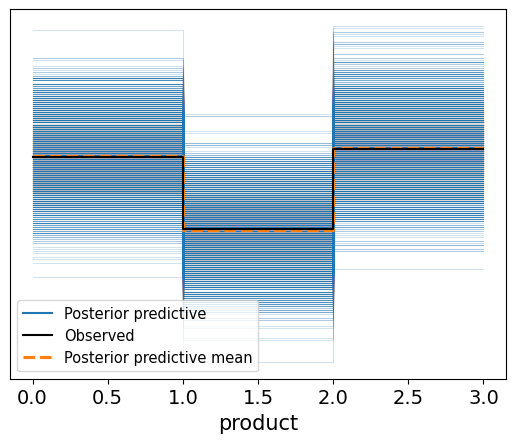

In [16]:
import arviz as az
import matplotlib.pyplot as plt

# posterior predictive samples
idata_ppc = bayes_multi_model.predict(
    bayes_multi_results,
    kind="pps",
    inplace=False
)

# posterior predictive check
az.plot_ppc(idata_ppc)
plt.show()

# =========================================
# MULTINOMIAL LOGISTIC REGRESSION (HEALTH INSURANCE)
# =========================================

## MODEL SETUP

Outcome:
    product ∈ {A, B, C}  (categorical, no natural ordering)

Likelihood:
    y_i ~ Categorical(p_A, p_B, p_C)

Reference Category:
    A (baseline for comparison)

---

## MODEL STRUCTURE

We model log-odds relative to the reference category:

    log(P(B) / P(A)) = β0_B + β1_B * age + ... + βp_B * x_p
    log(P(C) / P(A)) = β0_C + β1_C * age + ... + βp_C * x_p

---

## COEFFICIENT DEFINITIONS

β_jk:
    Change in log-odds of choosing category k (vs A)
    for a one-unit increase in predictor x_j,
    holding all other variables constant

exp(β_jk):
    Odds ratio → multiplicative change in odds of choosing k vs A

---

## FREQUENTIST INTERPRETATION (EXAMPLE: AGE)

### B vs A

Coefficient ≈ 0.244

Interpretation:
    A one-year increase in age increases the log-odds of choosing B vs A

Odds ratio:
    exp(0.244) ≈ 1.28

    → ~28% increase in odds of choosing B relative to A

---

### C vs A

Coefficient ≈ 0.270

Interpretation:
    A one-year increase in age increases the log-odds of choosing C vs A

Odds ratio:
    exp(0.270) ≈ 1.31

    → ~31% increase in odds of choosing C relative to A

---

## BAYESIAN INTERPRETATION (AGE)

### B vs A

Mean ≈ 0.244
HDI ≈ [0.216, 0.270]

Interpretation:
    A one-year increase in age multiplies the odds of choosing B vs A
    by approximately 1.24 to 1.31

    The HDI lies entirely above 0 → strong evidence of a positive effect

---

### C vs A

Mean ≈ 0.270
HDI ≈ [0.243, 0.299]

Interpretation:
    A one-year increase in age multiplies the odds of choosing C vs A
    by approximately 1.28 to 1.35

    The HDI lies entirely above 0 → strong evidence of a positive effect

---

## KEY MULTINOMIAL INSIGHT

- Each predictor has **multiple effects** (one per category comparison)
- Effects can differ across categories
- A variable can:
    increase odds for one category
    decrease odds for another

---

## POSTERIOR PREDICTIVE CHECK

Interpretation:
    The observed category frequencies lie within the posterior predictive distribution

Conclusion:
    The model provides an **adequate fit**, as it can generate data
    consistent with the observed outcomes

---

## CORE TAKEAWAYS

- Multinomial regression models **relative log-odds**
- Requires a **reference category** for identifiability
- Bayesian approach provides:
    direction + magnitude + uncertainty for each category comparison
- Posterior predictive checks validate overall model fit (not correctness)